# EDA: (Exploratory data analysis)

## Configuración y carga de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import cv2
import os
from PIL import Image

# Configuración de estilo de las gráficas
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ---------------------------------------------------------
# CONFIGURACIÓN DE RUTAS (Carpeta data en el directorio padre)
# ---------------------------------------------------------

# 1. Obtenemos el directorio donde está el notebook
current_dir = os.getcwd()

# 2. Obtenemos el directorio padre (subimos un nivel)
parent_dir = os.path.dirname(current_dir)

# 3. Construimos la ruta a la carpeta 'data' que está en el padre
data_dir = os.path.join(parent_dir, 'data')

# 4. Definimos las rutas a los archivos específicos
TRAIN_CSV = os.path.join(data_dir, 'new-train-metadata.csv')
TRAIN_HDF5 = os.path.join(data_dir, 'train-image.hdf5')
TEST_HDF5 = os.path.join(data_dir, 'test-image.hdf5')
TEST_CSV  = os.path.join(data_dir, 'students-test-metadata.csv')

# ---------------------------------------------------------
# VERIFICACIÓN DE ARCHIVOS
# ---------------------------------------------------------
print(f"Directorio del Notebook: {current_dir}")
print(f"Directorio Padre:        {parent_dir}")
print(f"Buscando datos en:       {data_dir}\n")

# Comprobamos si los archivos existen
files_to_check = {
    "Train Metadata": TRAIN_CSV,
    "Train Images": TRAIN_HDF5,
    "Test Metadata": TEST_CSV,
    "Test Images": TEST_HDF5
}

all_found = True
for name, path in files_to_check.items():
    if os.path.exists(path):
        print(f"✅ Encontrado {name}")
    else:
        print(f"❌ NO ENCONTRADO {name}: {path}")
        all_found = False

if all_found:
    print("\n¡Todo listo! Rutas configuradas correctamente.")
else:
   print("\n⚠️ ERROR: No se encuentran los archivos. Verifica que la carpeta 'data' esté en el nivel superior.")

Directorio del Notebook: /home/jorge/Documentos/Deep/ISIC_DL/ModelMaker
Directorio Padre:        /home/jorge/Documentos/Deep/ISIC_DL
Buscando datos en:       /home/jorge/Documentos/Deep/ISIC_DL/data

✅ Encontrado Train Metadata
✅ Encontrado Train Images
✅ Encontrado Test Metadata
✅ Encontrado Test Images

¡Todo listo! Rutas configuradas correctamente.


## Exploración inicialñ de metadatos:

In [6]:
# ---------------------------------------------------------
# 1. CARGA DE METADATOS
# ---------------------------------------------------------

# Cargar los dataframes
df_train = pd.read_csv(TRAIN_CSV)
df_test = pd.read_csv(TEST_CSV)

print(f"Dimensiones del Train Set: {df_train.shape}")
print(f"Dimensiones del Test Set:  {df_test.shape}")

# Vista previa
display(df_train.head(3))

# Información de tipos y nulos
print("\n--- Información del Dataset ---")
df_train.info()

# Identificar columnas numéricas y categóricas para el futuro modelo XGBoost
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_train.select_dtypes(include=['object']).columns.tolist()

print(f"\nColumnas Numéricas ({len(numeric_cols)}): {numeric_cols[:5]} ...")
print(f"Columnas Categóricas ({len(cat_cols)}): {cat_cols}")

/tmp/ipykernel_88915/3507194183.py:6: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df_train = pd.read_csv(TRAIN_CSV)


Dimensiones del Train Set: (400959, 55)
Dimensiones del Test Set:  (100, 44)


,isic_id,target,patient_id,age_approx,sex,anatom_site_general,clin_size_long_diam_mm,image_type,tbp_tile_type,tbp_lv_A,...,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0,IP_1235828,60.0,male,lower extremity,3.04,TBP tile: close-up,3D: white,20.244422,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0,IP_8170065,60.0,male,head/neck,1.10,TBP tile: close-up,3D: white,31.712570,...,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0,IP_6724798,60.0,male,posterior torso,3.40,TBP tile: close-up,3D: XP,22.575830,...,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040



--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400959 entries, 0 to 400958
Data columns (total 55 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   isic_id                       400959 non-null  object 
 1   target                        400959 non-null  int64  
 2   patient_id                    400959 non-null  object 
 3   age_approx                    398163 non-null  float64
 4   sex                           389446 non-null  object 
 5   anatom_site_general           395203 non-null  object 
 6   clin_size_long_diam_mm        400959 non-null  float64
 7   image_type                    400959 non-null  object 
 8   tbp_tile_type                 400959 non-null  object 
 9   tbp_lv_A                      400959 non-null  float64
 10  tbp_lv_Aext                   400959 non-null  float64
 11  tbp_lv_B                      400959 non-null  float64
 12  tbp_lv_Bext

## Conteo de clases

Benignos (0): 400616
Malignos (1): 343
Tasa de Malignidad: 0.0855%


/tmp/ipykernel_88915/2196074214.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=df_train, palette='viridis')


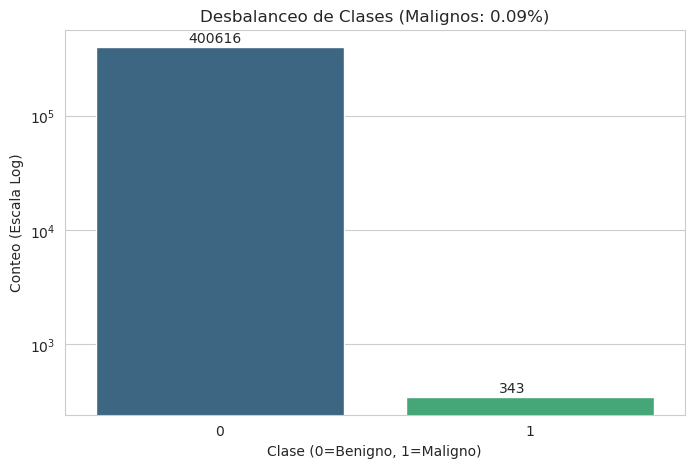

In [7]:
# ---------------------------------------------------------
# 2. ANÁLISIS DE LA VARIABLE OBJETIVO (TARGET)
# ---------------------------------------------------------

# Conteo de clases
target_counts = df_train['target'].value_counts()
benign_count = target_counts[0]
malignant_count = target_counts.get(1, 0)
total_count = len(df_train)

ratio_malignant = (malignant_count / total_count) * 100

print(f"Benignos (0): {benign_count}")
print(f"Malignos (1): {malignant_count}")
print(f"Tasa de Malignidad: {ratio_malignant:.4f}%")

# Gráfico
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='target', data=df_train, palette='viridis')
plt.title(f'Desbalanceo de Clases (Malignos: {ratio_malignant:.2f}%)')
plt.yscale('log') # Escala logarítmica porque si no la barra del 1 no se ve
plt.ylabel("Conteo (Escala Log)")
plt.xlabel("Clase (0=Benigno, 1=Maligno)")

# Añadir etiquetas
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() * 1.1))

plt.show()

## Análisis de variables clínicas

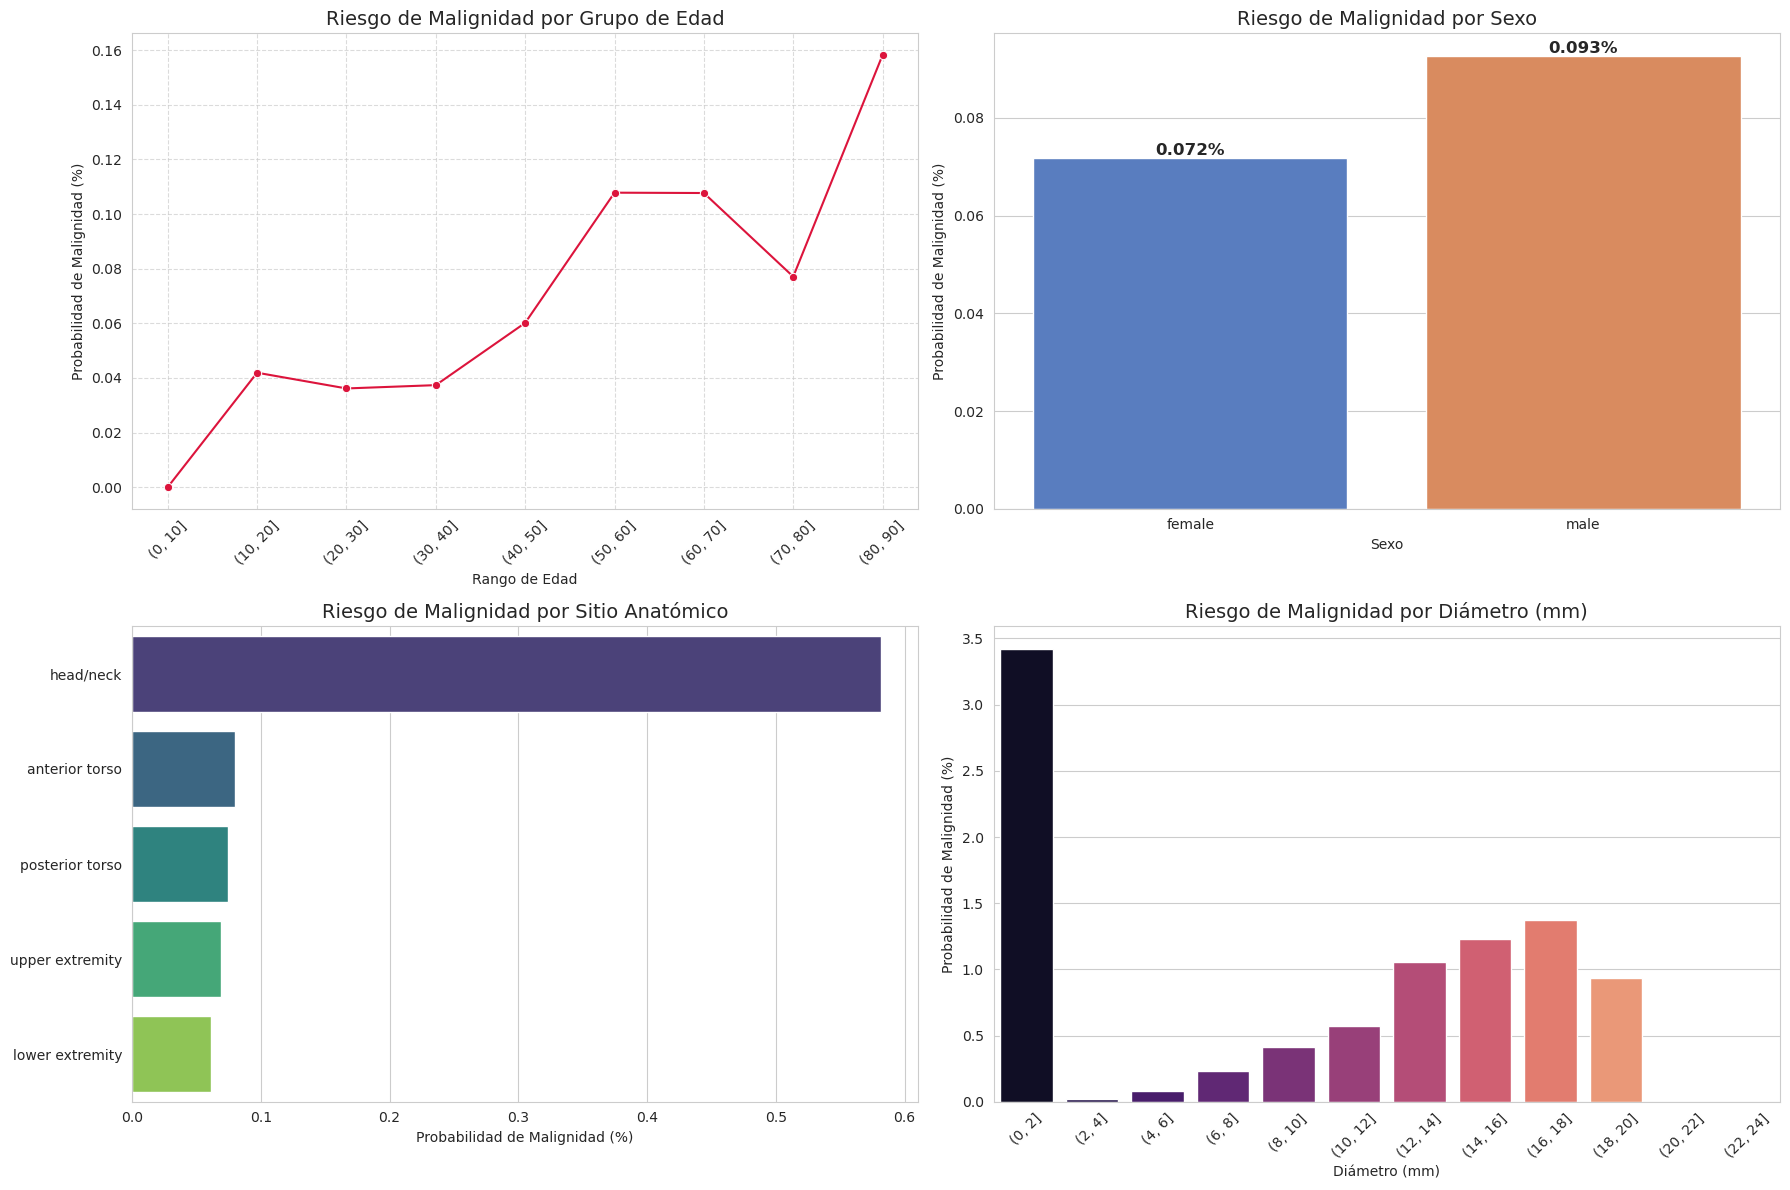


--- RESUMEN DE RIESGOS (Probabilidad condicionada) ---
Riesgo Global (Baseline): 0.086%
Riesgo Hombres: 0.093% vs Mujeres: 0.072%
Zona más peligrosa: head/neck (0.582%)


In [10]:
# ---------------------------------------------------------
# 3. ANÁLISIS DE RIESGO (PROBABILIDAD CONDICIONADA)
# ---------------------------------------------------------
# Lógica: P(Maligno | Variable) = Media del Target en ese grupo

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ---------------------------------------------------------
# 3.1 RIESGO POR EDAD (Binning)
# "Si tengo X años, ¿cuál es mi probabilidad de malignidad?"
# ---------------------------------------------------------
# Creamos tramos de edad de 5 años
df_clean_age = df_train.dropna(subset=['age_approx']).copy()
df_clean_age['age_bin'] = pd.cut(df_clean_age['age_approx'], bins=range(0, 95, 10))

# Calculamos el ratio (mean) por tramo
age_risk = df_clean_age.groupby('age_bin', observed=False)['target'].mean() * 100 # Multiplicamos por 100 para %

# Graficamos
sns.lineplot(x=age_risk.index.astype(str), y=age_risk.values, marker='o', color='crimson', ax=axes[0, 0])
axes[0, 0].set_title('Riesgo de Malignidad por Grupo de Edad', fontsize=14)
axes[0, 0].set_ylabel('Probabilidad de Malignidad (%)')
axes[0, 0].set_xlabel('Rango de Edad')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, linestyle='--', alpha=0.7)


# ---------------------------------------------------------
# 3.2 RIESGO POR SEXO
# "Si soy Hombre/Mujer, ¿cuál es la probabilidad?"
# ---------------------------------------------------------
# Calculamos explícitamente el ratio
sex_risk = df_train.groupby('sex')['target'].mean() * 100
sex_order = sex_risk.index.tolist()

bar_plot = sns.barplot(x=sex_risk.index, y=sex_risk.values, hue=sex_risk.index, palette='muted', legend=False, ax=axes[0, 1])

axes[0, 1].set_title('Riesgo de Malignidad por Sexo', fontsize=14)
axes[0, 1].set_ylabel('Probabilidad de Malignidad (%)')
axes[0, 1].set_xlabel('Sexo')

# Añadir el número exacto encima de la barra
for i, p in enumerate(bar_plot.patches):
    axes[0, 1].annotate(f'{p.get_height():.3f}%', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=12, fontweight='bold')


# ---------------------------------------------------------
# 3.3 RIESGO POR SITIO ANATÓMICO
# "Si la lesión está en el torso, ¿cuál es la probabilidad?"
# ---------------------------------------------------------
site_risk = df_train.groupby('anatom_site_general')['target'].mean() * 100
site_risk = site_risk.sort_values(ascending=False) # Ordenamos de mayor riesgo a menor

sns.barplot(x=site_risk.values, y=site_risk.index, hue=site_risk.index, palette='viridis', legend=False, ax=axes[1, 0])

axes[1, 0].set_title('Riesgo de Malignidad por Sitio Anatómico', fontsize=14)
axes[1, 0].set_xlabel('Probabilidad de Malignidad (%)')
axes[1, 0].set_ylabel('')


# ---------------------------------------------------------
# 3.4 RIESGO POR TAMAÑO DE LESIÓN (Binning)
# "Si mide X mm, ¿qué probabilidad hay de que sea cáncer?"
# ---------------------------------------------------------
# Filtramos nulos y creamos bins de tamaño (0-2mm, 2-4mm, etc hasta 20mm)
df_clean_size = df_train.dropna(subset=['clin_size_long_diam_mm']).copy()
# Limitamos a 25mm para evitar que outliers extremos ensucien la gráfica
df_clean_size = df_clean_size[df_clean_size['clin_size_long_diam_mm'] <= 25] 
df_clean_size['size_bin'] = pd.cut(df_clean_size['clin_size_long_diam_mm'], bins=range(0, 26, 2))

size_risk = df_clean_size.groupby('size_bin', observed=False)['target'].mean() * 100

sns.barplot(x=size_risk.index.astype(str), y=size_risk.values, hue=size_risk.index, palette='magma', legend=False, ax=axes[1, 1])

axes[1, 1].set_title('Riesgo de Malignidad por Diámetro (mm)', fontsize=14)
axes[1, 1].set_ylabel('Probabilidad de Malignidad (%)')
axes[1, 1].set_xlabel('Diámetro (mm)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Imprimir tabla resumen textual para verificar
print("\n--- RESUMEN DE RIESGOS (Probabilidad condicionada) ---")
print(f"Riesgo Global (Baseline): {df_train['target'].mean()*100:.3f}%")
print(f"Riesgo Hombres: {sex_risk.get('male', 0):.3f}% vs Mujeres: {sex_risk.get('female', 0):.3f}%")
print(f"Zona más peligrosa: {site_risk.idxmax()} ({site_risk.max():.3f}%)")

Antes de ver las imágenes, es fundamental entender la gráficas mostradas 

**Riesgo de malignidad por diámetro**: (Pico en 0-2mm, subida progresiva y corte en 22mm):

- El Pico en 0-2 mm (Sesgo de Selección): Clínicamente, una lesión de 1 mm es casi invisible. La regla ABCD del melanoma dice que es sospechosa si mide > 6 mm.

- ¿Por qué el pico? Si una lesión de 1 mm está en este dataset y ha sido biopsiada/etiquetada, es porque era extremadamente sospechosa ("Patito Feo", muy oscura o nueva). Los médicos no biopsian granos de arena benignos. Por tanto, la proporción de malignos en este grupo diminuto es artificialmente alta.

- Crecimiento hasta 16-18 mm: Aquí aplica la lógica estándar: cuanto más grande es una lesión irregular, más probabilidad de que sea cáncer (el tumor crece sin control).

- Corte en 20-22 mm (Limitación Técnica): Las imágenes TBP son "tiles" (recortes) de tamaño fijo (aprox 15x15mm o similar). Si una lesión mide 50 mm, no cabe en el recorte o el sistema la descarta. Por eso no hay datos más allá.

## Análisis de las imágenes


Generando visualización para: ALEATORIO (GENERAL)...


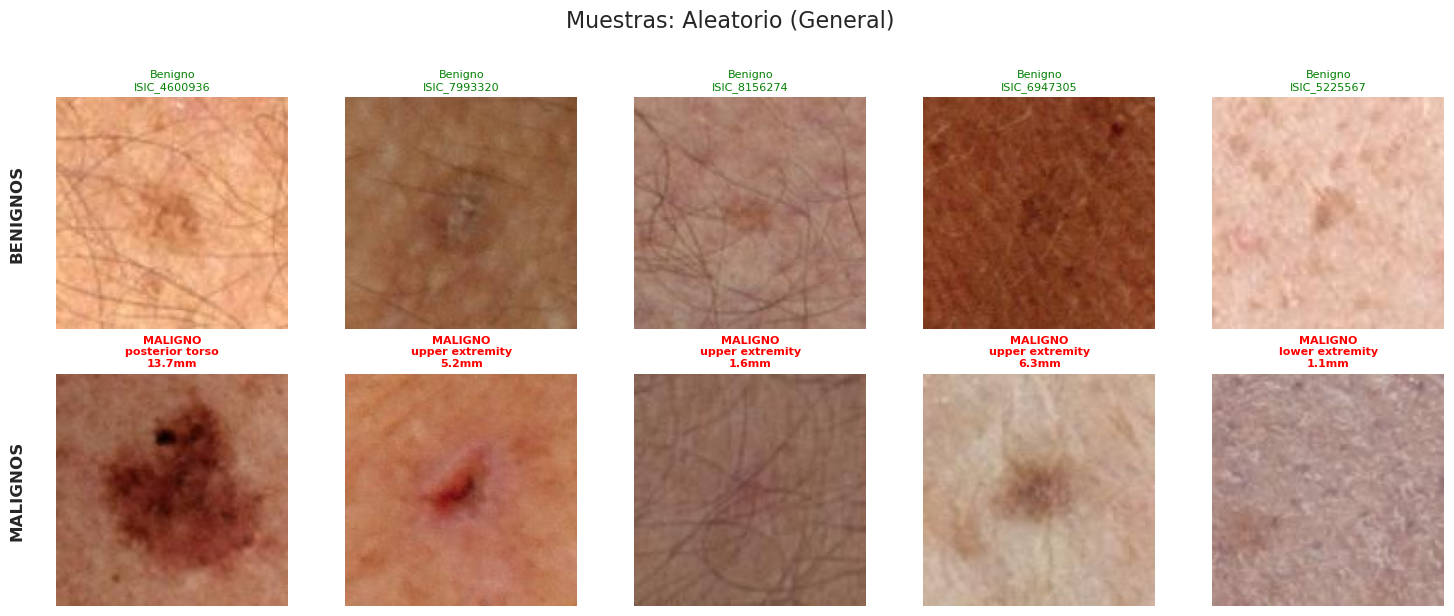


Generando visualización para: ZONA: CABEZA/CUELLO...


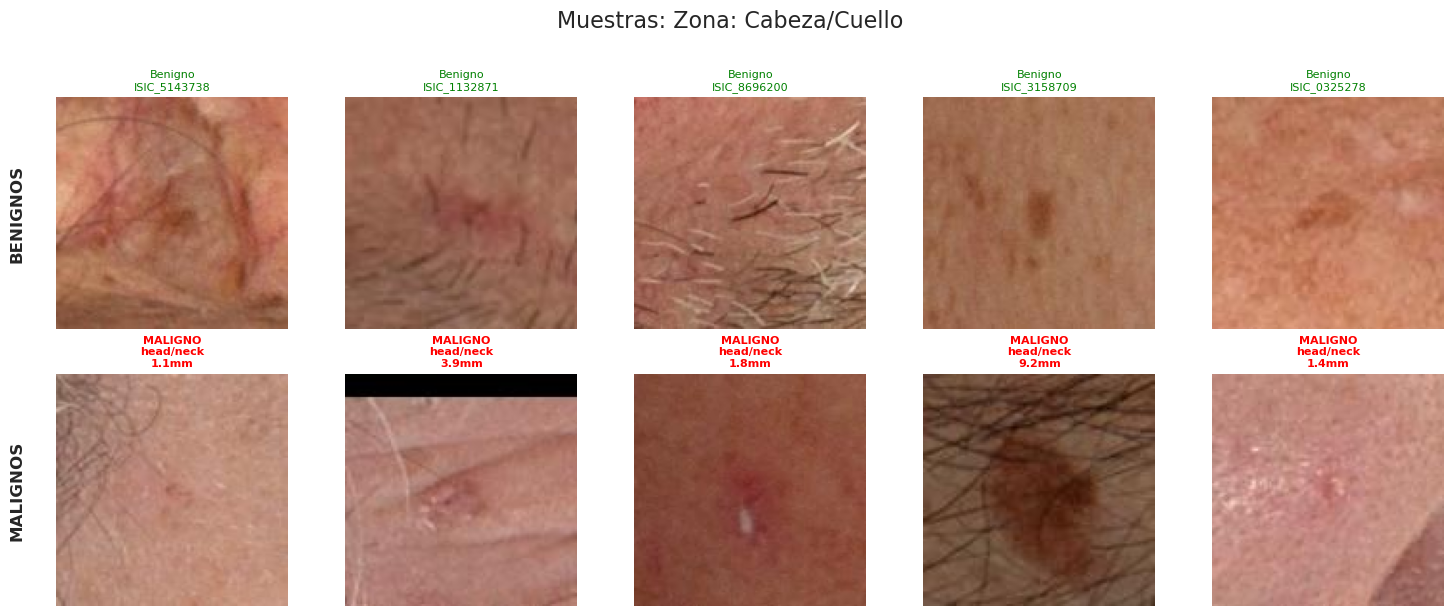


Generando visualización para: TAMAÑO: 0-2 MM (MICRO-LESIONES)...


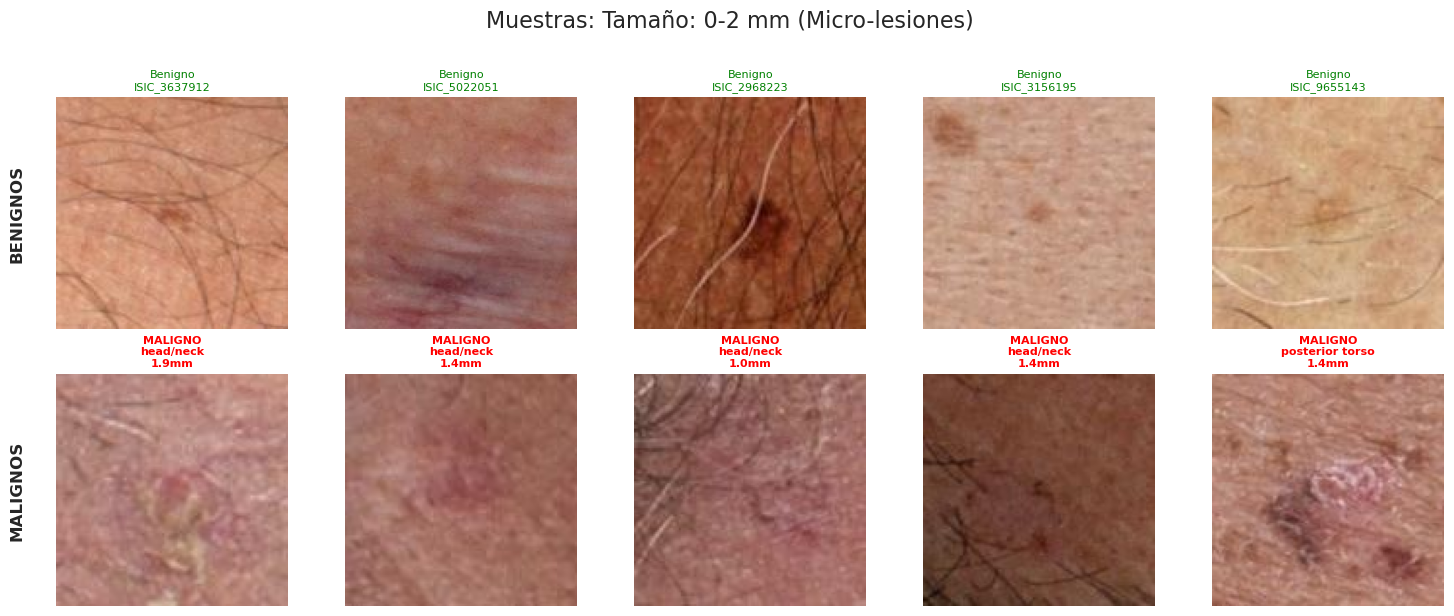

In [13]:
# ---------------------------------------------------------
# 4. ANÁLISIS VISUAL DE IMÁGENES
# ---------------------------------------------------------

def load_image_from_hdf5(isic_id, hdf5_path):
    """
    Lee una imagen específica de un archivo HDF5 usando su isic_id.
    """
    try:
        with h5py.File(hdf5_path, 'r') as hf:
            if isic_id not in hf:
                return None
            image_data = hf[isic_id][()]
            nparr = np.frombuffer(image_data, np.uint8)
            img_bgr = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            return img_rgb
    except Exception as e:
        print(f"Error leyendo {isic_id}: {e}")
        return None

def visualize_subset(df, criteria_name, hdf5_path, n_samples=5):
    """
    Visualiza una cuadrícula de imágenes Benignas vs Malignas dado un criterio de filtrado.
    """
    print(f"\nGenerando visualización para: {criteria_name.upper()}...")
    
    # Separar benignos y malignos del subset dado
    benign_subset = df[df['target'] == 0]
    malignant_subset = df[df['target'] == 1]
    
    # Verificar si hay suficientes muestras
    if len(malignant_subset) < n_samples:
        print(f"⚠️ Advertencia: Solo hay {len(malignant_subset)} malignos para este criterio.")
    
    # Muestreo aleatorio seguro
    n_b = min(len(benign_subset), n_samples)
    n_m = min(len(malignant_subset), n_samples)
    
    benign_ids = benign_subset.sample(n_b, random_state=42)['isic_id'].values
    malignant_ids = malignant_subset.sample(n_m, random_state=42)['isic_id'].values
    
    # Configurar plot
    fig, axes = plt.subplots(2, n_samples, figsize=(15, 6))
    plt.suptitle(f"Muestras: {criteria_name}", fontsize=16, y=1.02)
    
    # Fila 0: Benignos
    for i in range(n_samples):
        ax = axes[0, i]
        if i < len(benign_ids):
            pid = benign_ids[i]
            img = load_image_from_hdf5(pid, hdf5_path)
            if img is not None:
                ax.imshow(img)
                ax.set_title(f"Benigno\n{pid}", fontsize=8, color='green')
            else:
                ax.text(0.5, 0.5, "Error Load", ha='center')
        ax.axis('off')
        if i == 0: ax.text(-0.2, 0.5, "BENIGNOS", transform=ax.transAxes, rotation=90, fontsize=12, fontweight='bold', va='center')

    # Fila 1: Malignos
    for i in range(n_samples):
        ax = axes[1, i]
        if i < len(malignant_ids):
            pid = malignant_ids[i]
            img = load_image_from_hdf5(pid, hdf5_path)
            if img is not None:
                ax.imshow(img)
                # Añadimos info extra al título (Tamaño y Zona)
                meta = df[df['isic_id'] == pid].iloc[0]
                info = f"{meta.get('anatom_site_general', 'N/A')}\n{meta.get('clin_size_long_diam_mm', 0):.1f}mm"
                ax.set_title(f"MALIGNO\n{info}", fontsize=8, color='red', fontweight='bold')
            else:
                ax.text(0.5, 0.5, "Error Load", ha='center')
        ax.axis('off')
        if i == 0: ax.text(-0.2, 0.5, "MALIGNOS", transform=ax.transAxes, rotation=90, fontsize=12, fontweight='bold', va='center')

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# EJECUCIÓN DE LAS 3 PETICIONES
# ---------------------------------------------------------

# 1. CASO ALEATORIO (General)
visualize_subset(df_train, "Aleatorio (General)", TRAIN_HDF5)

# 2. CASO CABEZA/CUELLO (Zona de alto riesgo: 0.582%)
subset_neck = df_train[df_train['anatom_site_general'] == 'head/neck']
visualize_subset(subset_neck, "Zona: Cabeza/Cuello", TRAIN_HDF5)

# 3. CASO PEQUEÑOS (0 - 2 mm) - El "Pico" de probabilidad
# Filtramos lesiones minúsculas
subset_tiny = df_train[ (df_train['clin_size_long_diam_mm'] >= 0) & (df_train['clin_size_long_diam_mm'] <= 2) ]
visualize_subset(subset_tiny, "Tamaño: 0-2 mm (Micro-lesiones)", TRAIN_HDF5)